# **Pie Charts**


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-02-05 08:42:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  52.1MB/s    in 2.9s    

2026-02-05 08:42:54 (52.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [4]:
# Split multiple databases into separate rows
df_db = df.assign(DatabaseWantToWorkWith=df['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

# Count frequency of each database
db_counts = df_db['DatabaseWantToWorkWith'].value_counts().reset_index()
db_counts.columns = ['Database', 'Count']

# Select top 5
top5_db = db_counts.head(5)

Text(0.5, 1.0, 'Top 5 Databases Respondents Want to Work With')

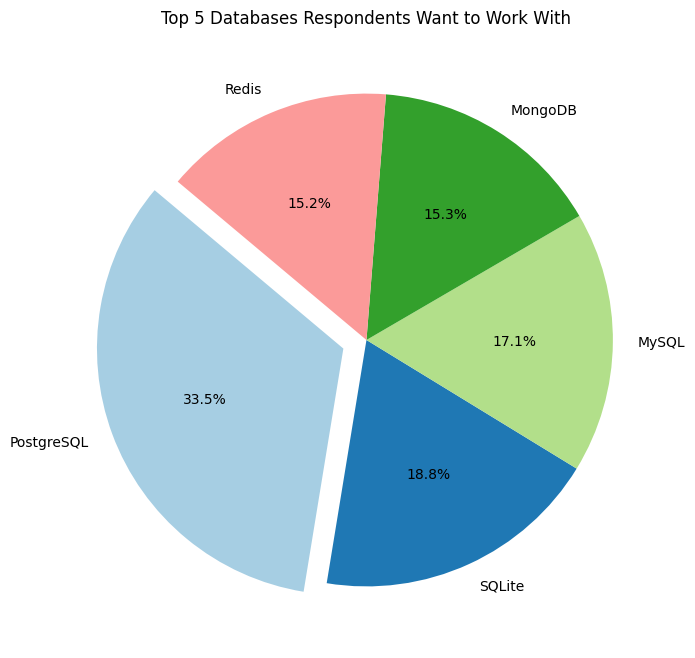

In [7]:
plt.figure(figsize=(8,8))
plt.pie(
    top5_db['Count'],
    labels=top5_db['Database'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0],   # explode the first slice
    colors=plt.cm.Paired.colors
)


plt.title("Top 5 Databases Respondents Want to Work With")

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [9]:
# Split multiple roles into separate rows
df_roles = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')
df_roles['DevType'] = df_roles['DevType'].str.strip()

# Count frequency of each role
role_counts = df_roles['DevType'].value_counts().reset_index()
role_counts.columns = ['DeveloperRole', 'Count']

# Select top 5 roles
top5_roles = role_counts.head(5)

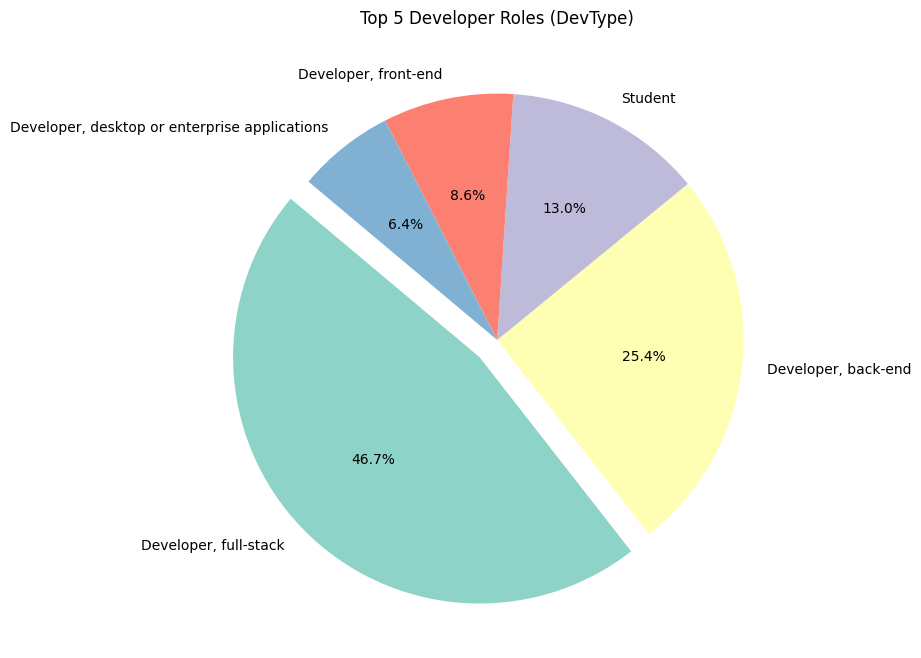

In [10]:
plt.figure(figsize=(8,8))

plt.pie(
    top5_roles['Count'],
    labels=top5_roles['DeveloperRole'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0],   # explode the first slice
    colors=plt.cm.Set3.colors
)

plt.title("Top 5 Developer Roles (DevType)")
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [12]:
# Split multiple OS entries into separate rows
df_os = df.assign(OpSysProfessional=df['OpSysProfessional use'].str.split(';')).explode('OpSysProfessional use')
df_os['OpSysProfessional use'] = df_os['OpSysProfessional use'].str.strip()

In [13]:
# Count frequency of each OS
os_counts = df_os['OpSysProfessional use'].value_counts().reset_index()
os_counts.columns = ['OperatingSystem', 'Count']

# Select top operating systems (e.g., top 5 or top 6 depending on dataset size)
top_os = os_counts.head(5)

Text(0.5, 1.0, 'Top Operating Systems Used Professionally')

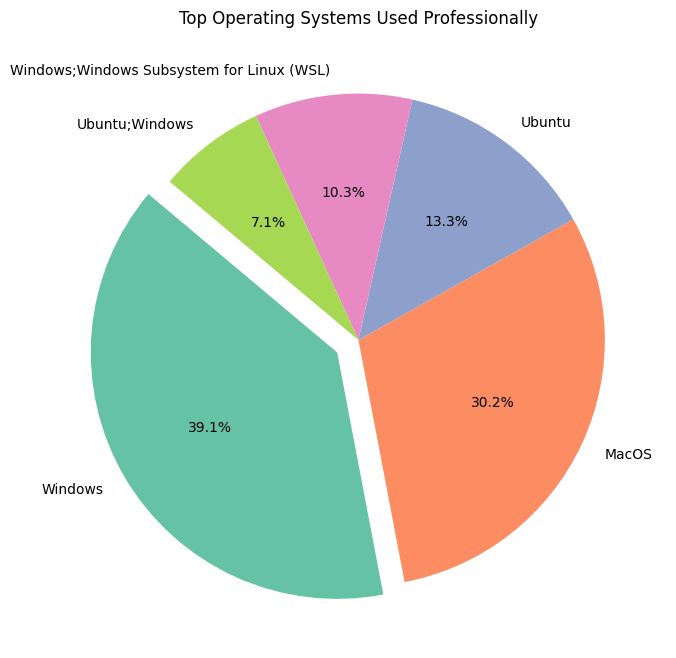

In [15]:
plt.figure(figsize=(8,8))

plt.pie(
    top_os['Count'],
    labels=top_os['OperatingSystem'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0],   # explode the first slice
    colors=plt.cm.Set2.colors
)

plt.title("Top Operating Systems Used Professionally")

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [16]:
# Split multiple languages into separate rows
df_lang = df.assign(LanguageHaveWorkedWith=df['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.strip()

In [17]:
# Count frequency of each language
lang_counts = df_lang['LanguageHaveWorkedWith'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Count']

# Select top 5 languages
top5_lang = lang_counts.head(5)

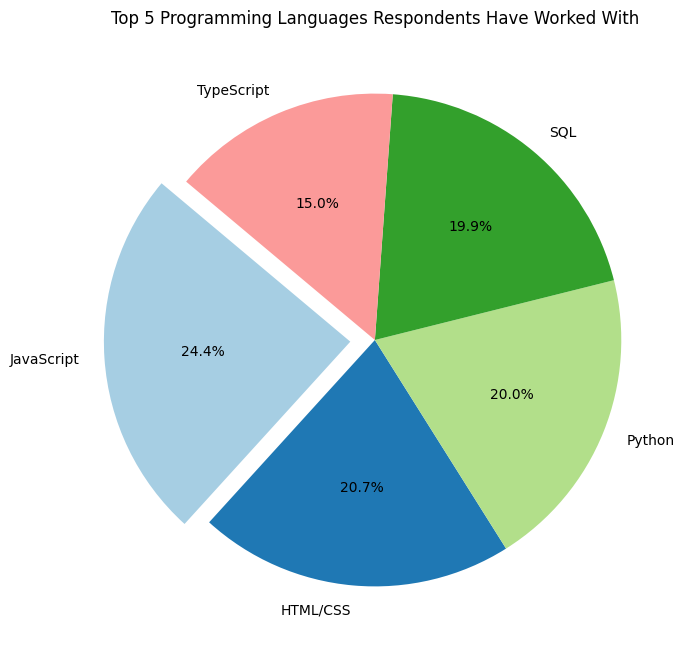

In [18]:
plt.figure(figsize=(8,8))

plt.pie(
    top5_lang['Count'],
    labels=top5_lang['Language'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0],   # explode the first slice
    colors=plt.cm.Paired.colors
)

plt.title("Top 5 Programming Languages Respondents Have Worked With")
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [19]:
# Split multiple collaboration tools into separate rows
df_tools = df.assign(NEWCollabToolsHaveWorkedWith=df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('NEWCollabToolsHaveWorkedWith')
df_tools['NEWCollabToolsHaveWorkedWith'] = df_tools['NEWCollabToolsHaveWorkedWith'].str.strip()

In [20]:
# Count frequency of each collaboration tool
tool_counts = df_tools['NEWCollabToolsHaveWorkedWith'].value_counts().reset_index()
tool_counts.columns = ['CollaborationTool', 'Count']

# Select top 5 tools
top5_tools = tool_counts.head(5)

Text(0.5, 1.0, 'Top Collaboration Tools Used Professionally')

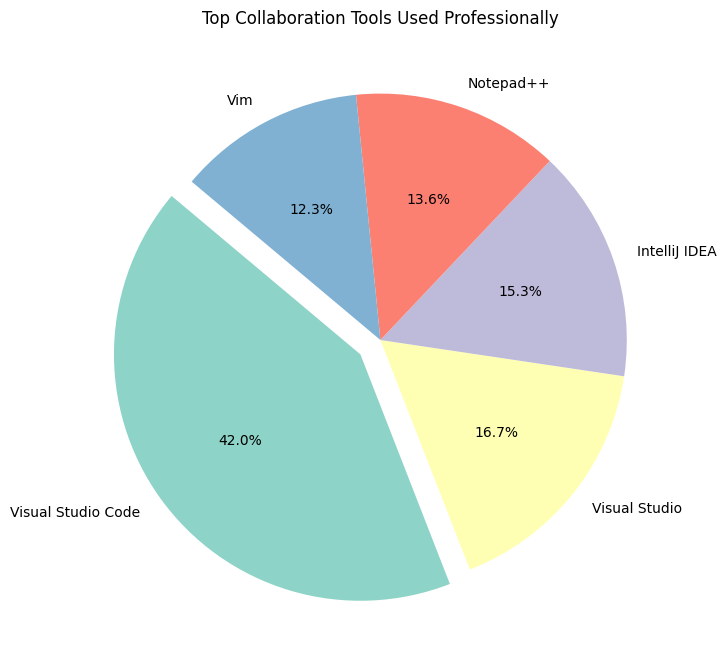

In [22]:
plt.figure(figsize=(8,8))

plt.pie(
    top5_tools['Count'],
    labels=top5_tools['CollaborationTool'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0],   # explode the first slice
    colors=plt.cm.Set3.colors
)

plt.title("Top Collaboration Tools Used Professionally")

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [25]:
# Split multiple admired languages into separate rows
df_admired = df.assign(LanguageAdmired=df['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')
df_admired['LanguageAdmired'] = df_admired['LanguageAdmired'].str.strip()

In [26]:
# Count frequency of each admired language
admired_counts = df_admired['LanguageAdmired'].value_counts().reset_index()
admired_counts.columns = ['Language', 'Count']

# Select top 5 admired languages
top5_admired = admired_counts.head(5)

Text(0.5, 1.0, 'Top 5 Most Admired Programming Languages')

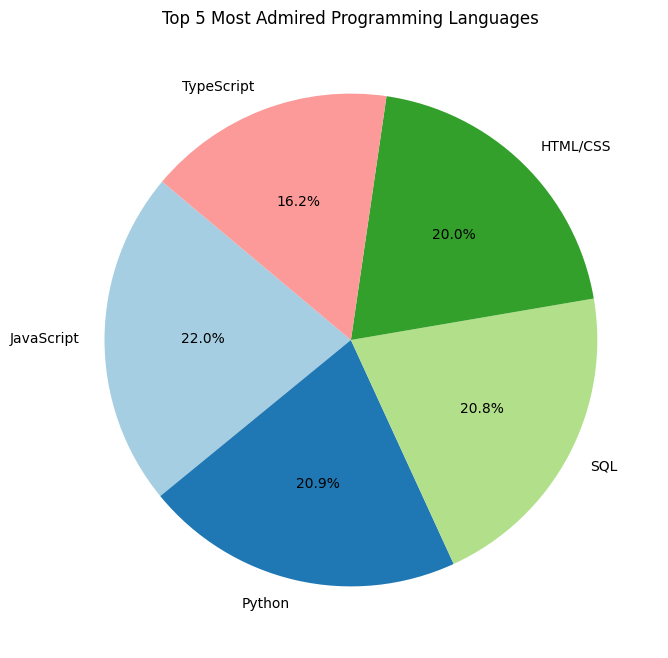

In [27]:
plt.figure(figsize=(8,8))

plt.pie(
    top5_admired['Count'],
    labels=top5_admired['Language'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title("Top 5 Most Admired Programming Languages")

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [29]:
# Split multiple AI tools into separate rows
df_ai = df.assign(AIToolCurrentlyUsing=df['AIToolCurrently Using'].str.split(';')).explode('AIToolCurrentlyUsing')
df_ai['AIToolCurrentlyUsing'] = df_ai['AIToolCurrentlyUsing'].str.strip()

# Count frequency of each AI tool
ai_counts = df_ai['AIToolCurrentlyUsing'].value_counts().reset_index()
ai_counts.columns = ['AITool', 'Count']

# Select top 5 tools
top5_ai = ai_counts.head(5)

Text(0.5, 1.0, 'Top 5 AI Tools Currently Used for Development')

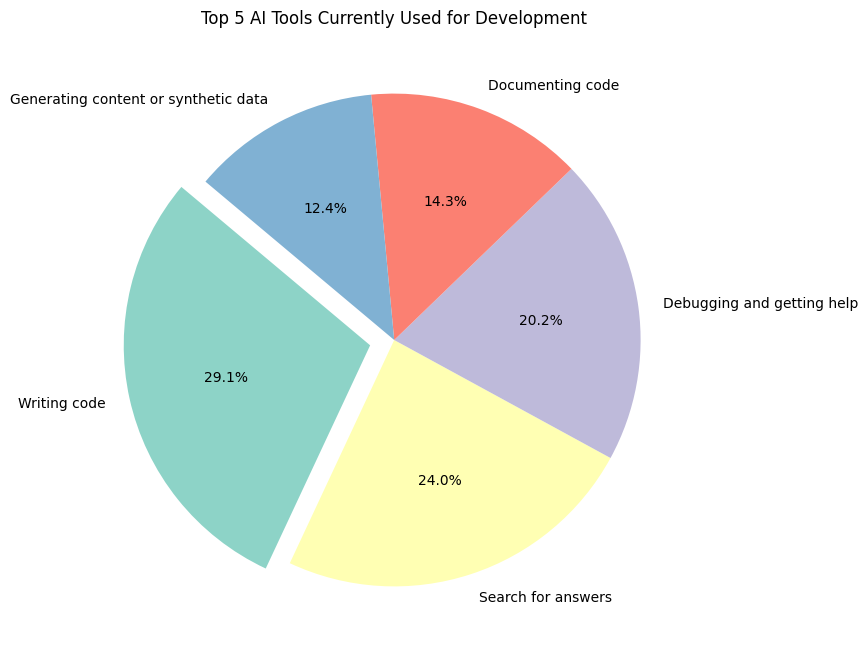

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    top5_ai['Count'],
    labels=top5_ai['AITool'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.1,0,0,0,0], 
    colors=plt.cm.Set3.colors
)

plt.title("Top 5 AI Tools Currently Used for Development")

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [32]:
# Split multiple frameworks into separate rows
df_web = df.assign(WebframeWantToWorkWith=df['WebframeWantToWorkWith'].str.split(';')).explode('WebframeWantToWorkWith')
df_web['WebframeWantToWorkWith'] = df_web['WebframeWantToWorkWith'].str.strip()

In [33]:
# Count frequency of each framework
framework_counts = df_web['WebframeWantToWorkWith'].value_counts().reset_index()
framework_counts.columns = ['Framework', 'Count']

# Select top 5 frameworks
top5_frameworks = framework_counts.head(5)

Text(0.5, 1.0, 'Top 5 Preferred Web Frameworks')

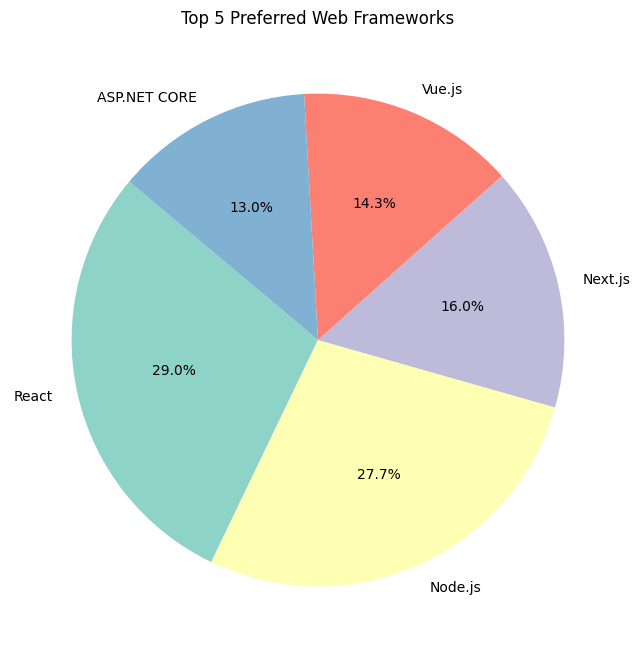

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    top5_frameworks['Count'],
    labels=top5_frameworks['Framework'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors
)

plt.title("Top 5 Preferred Web Frameworks")

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [35]:
# Split multiple embedded technologies into separate rows
df_embedded = df.assign(EmbeddedWantToWorkWith=df['EmbeddedWantToWorkWith'].str.split(';')).explode('EmbeddedWantToWorkWith')
df_embedded['EmbeddedWantToWorkWith'] = df_embedded['EmbeddedWantToWorkWith'].str.strip()

In [36]:
# Count frequency of each embedded technology
embedded_counts = df_embedded['EmbeddedWantToWorkWith'].value_counts().reset_index()
embedded_counts.columns = ['EmbeddedTech', 'Count']

# Select top 5 technologies
top5_embedded = embedded_counts.head(5)

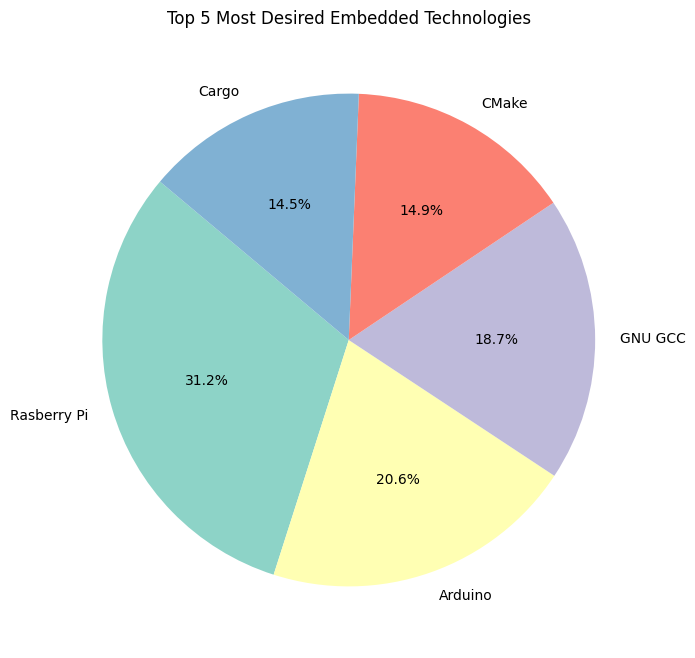

In [37]:
plt.figure(figsize=(8,8))

plt.pie(
    top5_embedded['Count'],
    labels=top5_embedded['EmbeddedTech'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors
)

plt.title("Top 5 Most Desired Embedded Technologies")
plt.show()

##### Insights: 
- Arduino and Raspberry Pi often lead due to accessibility and strong community support.
- ESP32 and STM32 are admired for IoT and industrial applications.
- ARM Cortex remains strong in professional embedded systems.

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


Copyright © IBM Corporation. All rights reserved.
